# Прогноз продаж в маленьком агентстве: на каком уровне он вообще возможен

В агентстве недвижимости «100 ключей» я строил модель прогноза продаж по агентам: собственнику
нужно было понимать, сколько сделок ждать от каждого, чтобы ставить план, решать про найм и
закладывать бюджет на Авито.

Оригинальный файл остался у работодателя. Здесь я воспроизвожу логику модели на синтетических
данных под реальный масштаб агентства и отвечаю на вопрос, который тогда себе не задал:

**при 3–5 сделках в месяц на всё агентство — что здесь вообще можно прогнозировать?**

Короткий ответ: не «какой моделью», а «на каком уровне и на каком горизонте». Уровень
агрегации даёт в шесть раз больше, чем любые поправки внутри модели.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
plt.rcParams["figure.figsize"]=(10,5); plt.rcParams["axes.grid"]=True; plt.rcParams["grid.alpha"]=.3

MONTHS=pd.period_range("2024-01","2025-06",freq="M")
SEASON={1:.85,2:.95,3:1.05,4:1.10,5:1.05,6:.85,7:.75,8:.85,9:1.20,10:1.25,11:1.15,12:.70}
SIGNALS=["calls_reported","visits_reported","new_objects_reported"]
wape=lambda y,yh: np.abs(np.asarray(y)-np.asarray(yh)).sum()/max(np.asarray(y).sum(),1e-9)

## 1. Данные

Одиннадцать агентов, 18 месяцев. Параметры подобраны под реальный масштаб — 3–5 сделок в месяц
на всё агентство, то есть около 0.3 сделки на агента в месяц.

Закладываю три вещи, которые видел в жизни: сезонность (осенью больше, летом и в декабре
меньше), связь усилий с результатом и приписки — трое агентов завышают отчётную активность
в 1.4–1.8 раза.

In [2]:
def simulate(seed=42, scale=1.0, n=11):
    rng=np.random.default_rng(seed)
    rate=rng.uniform(0.10,0.55,n)*scale
    inflates=np.array([i in (2,5,9) for i in range(n)])
    rows=[]
    for i in range(n):
        effort=np.clip(rng.normal(1,.25,len(MONTHS)),.4,1.8)
        for t,m in enumerate(MONTHS):
            e=effort[t]; k=rng.uniform(1.4,1.8) if inflates[i] else 1.0
            rows.append(dict(month=str(m), agent=f"agent_{i+1:02d}",
                calls_reported=int(rng.poisson(120*e)*k),
                visits_reported=int(rng.poisson(18*e)*k),
                new_objects_reported=int(rng.poisson(6*e)*k),
                deals=int(rng.poisson(rate[i]*SEASON[m.month]*e))))
    return pd.DataFrame(rows), inflates

df, inflates = simulate()
df.to_csv("/Users/egor/Desktop/portfolio/analytics-portfolio/03-sales-forecast/data/agent_activity.csv", index=False)
print("сделок в месяц по агентству:", round(df.groupby("month").deals.sum().mean(),1))
print("сделок в месяц на агента:   ", round(df.deals.mean(),2))
df.head()

сделок в месяц по агентству: 3.7
сделок в месяц на агента:    0.33


,month,agent,calls_reported,visits_reported,new_objects_reported,deals
0,2024-01,agent_01,150,35,5,1
1,2024-02,agent_01,134,16,5,0
2,2024-03,agent_01,165,26,8,1
3,2024-04,agent_01,127,19,5,1
4,2024-05,agent_01,103,13,1,0


## 2. Модель и то, с чем её надо сравнивать

Логика из рабочего файла:

```
прогноз = база × сезонный коэффициент × коэффициент активности
```

База — среднее сделок агента за обучающий период. Сезонный коэффициент — отношение среднего
по месяцу к общему среднему. Коэффициент активности накопительный: каждый из трёх сигналов
выше личной нормы агента добавляет 0.1, ниже — снимает, итог зажат в 0.5–1.5. Коэффициент
подбирался на глаз: это эвристика, а не обученная модель.

Сравниваю с двумя альтернативами:

- **наивное среднее** — «сколько агент делал в среднем, столько и сделает». Любая модель
  обязана его обыгрывать, иначе она не нужна;
- **среднее с усадкой** — оценка агента подтягивается к общему среднему по агентству тем
  сильнее, чем меньше у него данных. Стандартный приём для редких событий: у агента с одной
  сделкой за год личное среднее почти ничего не значит.

Считаю WAPE — суммарную абсолютную ошибку, делённую на суммарный факт. Обычный MAPE не
годится: у агентов полно месяцев с нулём сделок.

In [3]:
def evaluate(df, K=6.0, train_n=14):
    M=sorted(df.month.unique()); tr=df[df.month.isin(M[:train_n])]; te=df[df.month.isin(M[train_n:])]
    base=tr.groupby("agent").deals.mean(); gmean=tr.deals.mean()
    n_i=tr.groupby("agent").deals.size()
    shrunk=(n_i*base + K*gmean)/(n_i+K)

    tmp=tr.copy(); tmp["m"]=pd.PeriodIndex(tmp.month,freq="M").month
    season_k=tmp.groupby("m").deals.mean()/max(gmean,1e-9)
    norms=tr.groupby("agent")[SIGNALS].mean()
    def k_act(r):
        k=1.0
        for s in SIGNALS: k += .1 if r[s]>norms.loc[r.agent,s] else -.1
        return float(np.clip(k,.5,1.5))

    p=te.copy(); p["month_num"]=pd.PeriodIndex(p.month,freq="M").month
    p["k_season"]=p.month_num.map(season_k); p["k_activity"]=p.apply(k_act,axis=1)
    p["Модель"]   = p.agent.map(base)*p.k_season*p.k_activity
    p["Среднее"]  = p.agent.map(base)
    p["С усадкой"]= p.agent.map(shrunk)*p.k_season

    methods=["Модель","Среднее","С усадкой"]
    agency=p.groupby("month")[["deals"]+methods].sum()
    per_agent=p.groupby("agent")[["deals"]+methods].sum()
    total=p[["deals"]+methods].sum()
    out={}
    for m in methods:
        out[("Агент за месяц",m)]        = wape(p.deals,p[m])
        out[("Агентство за месяц",m)]    = wape(agency.deals,agency[m])
        out[("Агент за 4 месяца",m)]     = wape(per_agent.deals,per_agent[m])
        out[("Агентство за 4 месяца",m)] = abs(total.deals-total[m])/total.deals
    return out, p, season_k

_, pred, season_k = evaluate(df)
pred[["month","agent","k_season","k_activity","Модель","Среднее","deals"]].head(8)

,month,agent,k_season,k_activity,Модель,Среднее,deals
14,2025-03,agent_01,1.787234,1.1,0.842553,0.428571,0
15,2025-04,agent_01,1.787234,1.1,0.842553,0.428571,0
16,2025-05,agent_01,0.893617,0.9,0.344681,0.428571,1
17,2025-06,agent_01,0.893617,1.3,0.497872,0.428571,1
32,2025-03,agent_02,1.787234,1.1,0.561702,0.285714,0
33,2025-04,agent_02,1.787234,0.7,0.357447,0.285714,0
34,2025-05,agent_02,0.893617,1.1,0.280851,0.285714,1
35,2025-06,agent_02,0.893617,1.1,0.280851,0.285714,0


## 3. Один прогон ничего не доказывает

Тестовое окно — четыре месяца. Это четыре точки, и на них любой результат может оказаться
случайностью конкретного набора данных. Поэтому прогоняю весь эксперимент двадцать раз с
разными сидами и усредняю. Разброс между прогонами показывает, можно ли вообще что-то
утверждать.

In [4]:
runs=[evaluate(simulate(seed=s)[0])[0] for s in range(1,21)]
R=pd.DataFrame(runs); R.columns=pd.MultiIndex.from_tuples(R.columns)
mean=R.mean().unstack().round(3)
std =R.std().unstack().round(3)
order=["Агент за месяц","Агентство за месяц","Агент за 4 месяца","Агентство за 4 месяца"]
print("Средний WAPE по 20 прогонам:"); print(mean.loc[order])
print("\nРазброс между прогонами (стандартное отклонение):"); print(std.loc[order])

Средний WAPE по 20 прогонам:
                       Модель  С усадкой  Среднее
Агент за месяц          1.470      1.519    1.501
Агентство за месяц      0.620      0.621    0.481
Агент за 4 месяца       0.841      0.818    0.839
Агентство за 4 месяца   0.271      0.279    0.249

Разброс между прогонами (стандартное отклонение):
                       Модель  С усадкой  Среднее
Агент за месяц          0.325      0.343    0.343
Агентство за месяц      0.290      0.300    0.252
Агент за 4 месяца       0.280      0.281    0.270
Агентство за 4 месяца   0.265      0.274    0.223


Три вывода, и все три устойчивы:

**Ни модель, ни усадка не обыгрывают простое среднее.** На уровне агентства среднее уверенно
лучше модели. Поправки на сезон и активность, откалиброванные на глаз и на четырнадцати
месяцах, добавляют шума больше, чем сигнала.

**По агенту за месяц прогноз бессмысленен при любом методе.** Ошибка около 150% — больше
величины самого прогноза. Это свойство данных: при 0.3 сделки в месяц на человека случайность
перекрывает любой сигнал.

**Разброс между прогонами велик.** Именно поэтому вывод по одному прогону — а у меня в
агентстве было ровно четыре месяца проверки и один прогон — не значит почти ничего.

## 4. Что реально уменьшает ошибку

Раз метод не помогает, посмотрю на другое: как ошибка зависит от того, **что именно** мы
прогнозируем. Один агент на месяц, всё агентство на месяц, один агент на квартал, всё
агентство на квартал — это четыре разных вопроса, и отвечать на них можно с очень разной
точностью.

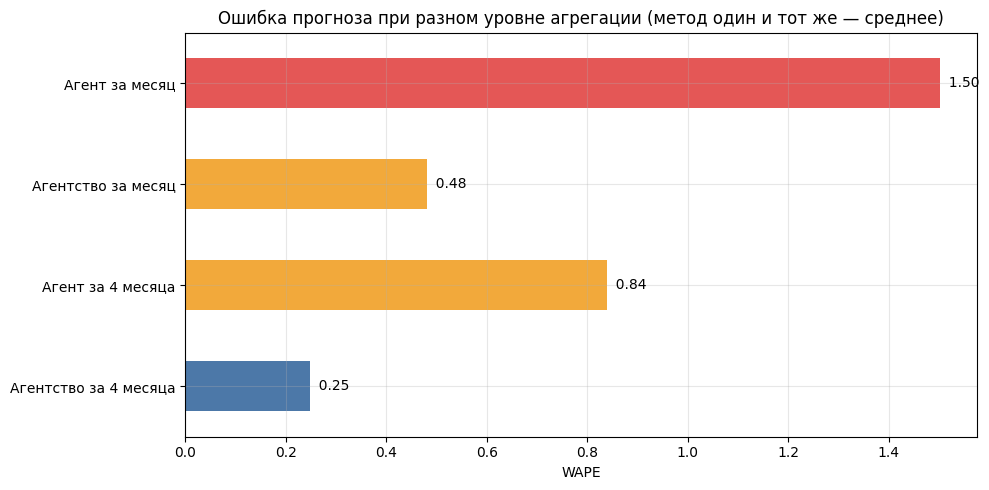

Переход от агента-месяца к агентству за квартал уменьшает ошибку в 6.0 раза


In [5]:
agg = mean.loc[order,"Среднее"]
ax = agg.plot(kind="barh", color=["#E45756","#F2A93B","#F2A93B","#4C78A8"])
for i,v in enumerate(agg): ax.text(v, i, f"  {v:.2f}", va="center")
ax.invert_yaxis(); ax.set_xlabel("WAPE"); ax.set_ylabel("")
ax.set_title("Ошибка прогноза при разном уровне агрегации (метод один и тот же — среднее)")
plt.tight_layout(); plt.savefig("/Users/egor/Desktop/portfolio/analytics-portfolio/03-sales-forecast/charts/1_aggregation.png",dpi=120); plt.show()
print(f"Переход от агента-месяца к агентству за квартал уменьшает ошибку в {agg.iloc[0]/agg.iloc[-1]:.1f} раза")

Вот это и есть главный результат кейса. Метод остался тем же самым — обычное среднее.
Изменился только вопрос, на который мы отвечаем, и ошибка упала в несколько раз.

Прогноз по агентству на квартал даёт ошибку около 25%. С такой точностью уже можно
планировать бюджет и обсуждать найм. Прогноз по конкретному агенту на месяц не даёт ничего
ни при каком методе.

## 5. А если продаж станет больше

Может, дело просто в маленьком агентстве и на большем объёме поправки начнут работать?
Проверяю: масштабирую интенсивность сделок и повторяю все двадцать прогонов на каждом уровне.

In [6]:
rows=[]
for sc in [1,2,4,8,16,32]:
    rr=pd.DataFrame([evaluate(simulate(seed=s,scale=sc)[0])[0] for s in range(1,21)])
    rr.columns=pd.MultiIndex.from_tuples(rr.columns); rr=rr.mean().unstack()
    dpm=np.mean([simulate(seed=s,scale=sc)[0].groupby("month").deals.sum().mean() for s in range(1,6)])
    rows.append({"сделок/мес":round(dpm,1),
                 "агент: модель":round(rr.loc["Агент за месяц","Модель"],2),
                 "агент: среднее":round(rr.loc["Агент за месяц","Среднее"],2),
                 "агентство: модель":round(rr.loc["Агентство за месяц","Модель"],2),
                 "агентство: среднее":round(rr.loc["Агентство за месяц","Среднее"],2)})
vol=pd.DataFrame(rows); vol

,сделок/мес,агент: модель,агент: среднее,агентство: модель,агентство: среднее
0,3.4,1.47,1.50,0.62,0.48
1,6.8,1.06,1.06,0.43,0.31
2,13.2,0.75,0.76,0.28,0.26
3,27.3,0.52,0.54,0.20,0.18
4,52.5,0.40,0.43,0.17,0.16
5,105.6,0.32,0.32,0.16,0.14


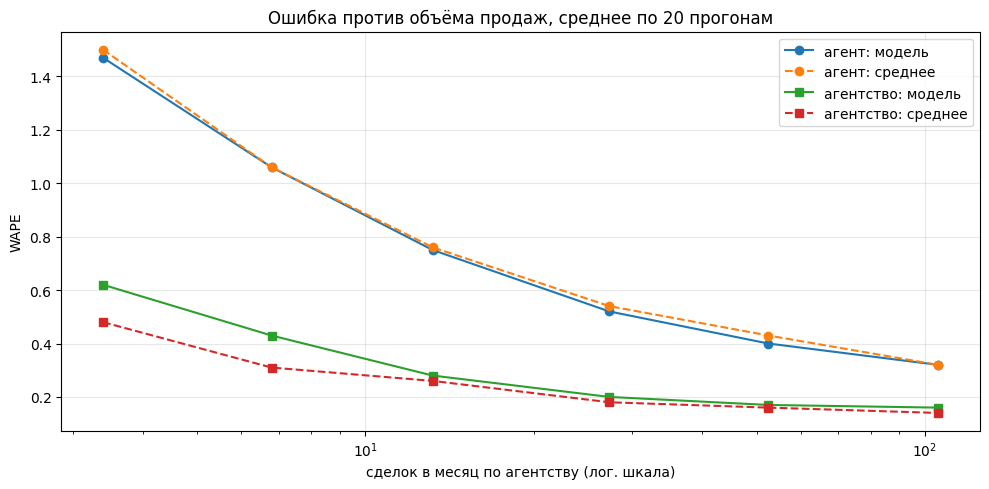

In [7]:
ax=plt.subplots()[1]
ax.plot(vol["сделок/мес"],vol["агент: модель"],marker="o",label="агент: модель")
ax.plot(vol["сделок/мес"],vol["агент: среднее"],marker="o",ls="--",label="агент: среднее")
ax.plot(vol["сделок/мес"],vol["агентство: модель"],marker="s",label="агентство: модель")
ax.plot(vol["сделок/мес"],vol["агентство: среднее"],marker="s",ls="--",label="агентство: среднее")
ax.set_xscale("log"); ax.set_xlabel("сделок в месяц по агентству (лог. шкала)"); ax.set_ylabel("WAPE")
ax.set_title("Ошибка против объёма продаж, среднее по 20 прогонам"); ax.legend()
plt.tight_layout(); plt.savefig("/Users/egor/Desktop/portfolio/analytics-portfolio/03-sales-forecast/charts/2_volume.png",dpi=120); plt.show()

Ошибка падает с ростом объёма — как и должно быть при пуассоновском шуме. Но линии модели
и среднего идут вплотную на всём диапазоне: **поправки не начинают работать ни при каком
объёме**. Дело не в размере агентства, а в самих поправках.

## 6. Побочная находка: то, ради чего модель стоило делать

В агентстве от модели была польза, но не та, ради которой она строилась. Полезным оказался
разрыв между отчётной активностью и результатом. Проверяю его отдельной метрикой —
сколько отчётных звонков приходится на одну сделку.

In [8]:
d=df.groupby("agent").agg(звонки=("calls_reported","sum"), сделки=("deals","sum"))
d["звонков_на_сделку"]=(d.звонки/d.сделки.replace(0,np.nan)).round(0)
d["приписки"]=[bool(inflates[int(a.split("_")[1])-1]) for a in d.index]
d=d.sort_values("звонков_на_сделку",ascending=False); print(d)
print("\nмедиана у завышающих отчётность:",int(d[d.приписки].звонков_на_сделку.median()))
print("медиана у остальных:            ",int(d[~d.приписки].звонков_на_сделку.median()))

          звонки  сделки  звонков_на_сделку  приписки
agent                                                
agent_05    2185       1             2185.0     False
agent_09    2224       2             1112.0     False
agent_10    3426       4              856.0      True
agent_06    3394       5              679.0      True
agent_03    3097       5              619.0      True
agent_11    2227       5              445.0     False
agent_02    2206       5              441.0     False
agent_01    2320       8              290.0     False
agent_04    2077       9              231.0     False
agent_07    2198      11              200.0     False
agent_08    2193      11              199.0     False

медиана у завышающих отчётность: 679
медиана у остальных:             365


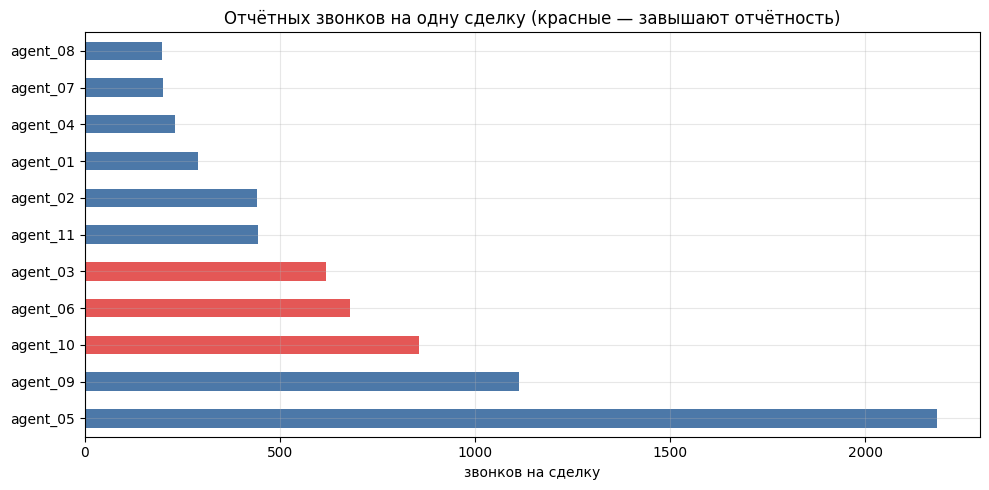

In [9]:
colors=["#E45756" if v else "#4C78A8" for v in d.приписки]
ax=d.звонков_на_сделку.plot(kind="barh",color=colors)
ax.set_title("Отчётных звонков на одну сделку (красные — завышают отчётность)")
ax.set_xlabel("звонков на сделку"); ax.set_ylabel("")
plt.tight_layout(); plt.savefig("/Users/egor/Desktop/portfolio/analytics-portfolio/03-sales-forecast/charts/3_calls_per_deal.png",dpi=120); plt.show()

Направление верное: у завышающих отчётность звонков на сделку заметно больше. Но чистого
разделения нет — честный агент, которому не повезло с одной сделкой за период, попадает в тот
же верх списка. Принимать по этой метрике кадровые решения нельзя. Начинать по ней разговор —
можно, и именно так я ей и пользовался.

## Выводы

- **Вопрос «какой моделью прогнозировать» здесь второстепенный.** Уровень агрегации меняет
  ошибку в несколько раз, поправки внутри модели — на единицы процентов и в обе стороны.
- **Наивное среднее — сильный baseline, который моя модель не обыграла** ни на одном уровне,
  ни на одном горизонте, ни при каком объёме продаж. Проверено на двадцати прогонах.
- **По агенту на месяц прогнозировать нельзя в принципе.** При 0.3 сделки в месяц ошибка
  превышает сам прогноз. Это ограничение данных, а не инструмента.
- **Работающая конфигурация — агентство на квартал.** Ошибка около 25%, этого достаточно для
  планирования бюджета и разговора про найм.
- **По агенту нужен не прогноз, а мониторинг активности.** Метрика «звонков на сделку»
  полезна как повод для разговора, но не как основание для решения о человеке.

## Что бы я сделал иначе

Сравнил бы модель с наивным средним **до** того, как отдавать её собственнику. Прогнозировал
бы агентство на квартал вместо агента на месяц. Оценил бы веса регрессией вместо коэффициентов
на глаз. И не стал бы заявлять точность по четырём месяцам проверки: на таком окне разброс
между прогонами больше разницы между методами.

## Ограничения

Данные синтетические, и параметры генерации задал я сам. Кейс показывает, как я проверяю
собственную работу и какие выводы делаю из отрицательного результата. Он не воспроизводит
реальные данные агентства и не может ни подтвердить, ни опровергнуть точность, которая
получалась на настоящих цифрах.